# 🧠 Brain Tumor MRI Classification with Vision Transformer (ViT)

**Dataset:** [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)  
**Classes:** `glioma` | `meningioma` | `notumor` | `pituitary`  
**Model:** Vision Transformer (ViT) — built from scratch + pretrained option

---
### Pipeline
1. Dataset loading & EDA
2. Image preprocessing & augmentation
3. Vision Transformer model definition
4. Training loop with loss/accuracy tracking
5. Confusion matrix & evaluation
6. Sample predictions visualization

## 1. Install & Import Libraries

In [24]:
# Install if needed
# !pip install timm torchvision torch matplotlib seaborn scikit-learn tqdm

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 2. Configuration

In [22]:
DATA_ROOT = Path('/Users/ananyayyadav/Desktop/brain tumor mri ')
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR  = DATA_ROOT / 'Testing'

assert DATA_ROOT.exists(), f'ERROR: {DATA_ROOT}'
assert TRAIN_DIR.exists(), f'ERROR: {TRAIN_DIR}'
assert TEST_DIR.exists(),  f'ERROR: {TEST_DIR}'
print(f'✓ DATA_ROOT : {DATA_ROOT}')
print(f'✓ TRAIN_DIR : {TRAIN_DIR}')
print(f'✓ TEST_DIR  : {TEST_DIR}')

IMG_SIZE     = 224
PATCH_SIZE   = 16
BATCH_SIZE   = 32
NUM_EPOCHS   = 20
LR           = 3e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 4
CLASSES      = ['glioma', 'meningioma', 'notumor', 'pituitary']

EMBED_DIM  = 256
DEPTH      = 6
NUM_HEADS  = 8
MLP_RATIO  = 4
DROPOUT    = 0.1

print('Configuration loaded ✓')

✓ DATA_ROOT : /Users/ananyayyadav/Desktop/brain tumor mri 
✓ TRAIN_DIR : /Users/ananyayyadav/Desktop/brain tumor mri /Training
✓ TEST_DIR  : /Users/ananyayyadav/Desktop/brain tumor mri /Testing
Configuration loaded ✓


In [20]:
import os
from pathlib import Path

desktop = Path('/Users/ananyayyadav/Desktop')
print("Folders on Desktop containing 'brain' or 'tumor' or 'mri':")
for item in desktop.iterdir():
    if any(word in item.name.lower() for word in ['brain', 'tumor', 'mri']):
        print(f"  EXACT NAME: '{item.name}'")
        print(f"  FULL PATH : '{item}'")

Folders on Desktop containing 'brain' or 'tumor' or 'mri':
  EXACT NAME: 'brain tumor mri '
  FULL PATH : '/Users/ananyayyadav/Desktop/brain tumor mri '
  EXACT NAME: 'BrainTumor_ViT_Architecture.html'
  FULL PATH : '/Users/ananyayyadav/Desktop/BrainTumor_ViT_Architecture.html'


In [21]:
from pathlib import Path

DATA_ROOT = Path('/Users/ananyayyadav/Desktop/brain tumor mri ')
print("Root exists:", DATA_ROOT.exists())
print("\nContents:")
for item in sorted(DATA_ROOT.iterdir()):
    print(f"  '{item.name}'")

Root exists: True

Contents:
  'Testing'
  'Training'


## 3. Exploratory Data Analysis

Training samples per class:
  glioma         : 1400
  meningioma     : 1400
  notumor        : 1400
  pituitary      : 1400
  TOTAL          : 5600

Testing samples per class:
  glioma         : 400
  meningioma     : 400
  notumor        : 400
  pituitary      : 400
  TOTAL          : 1600


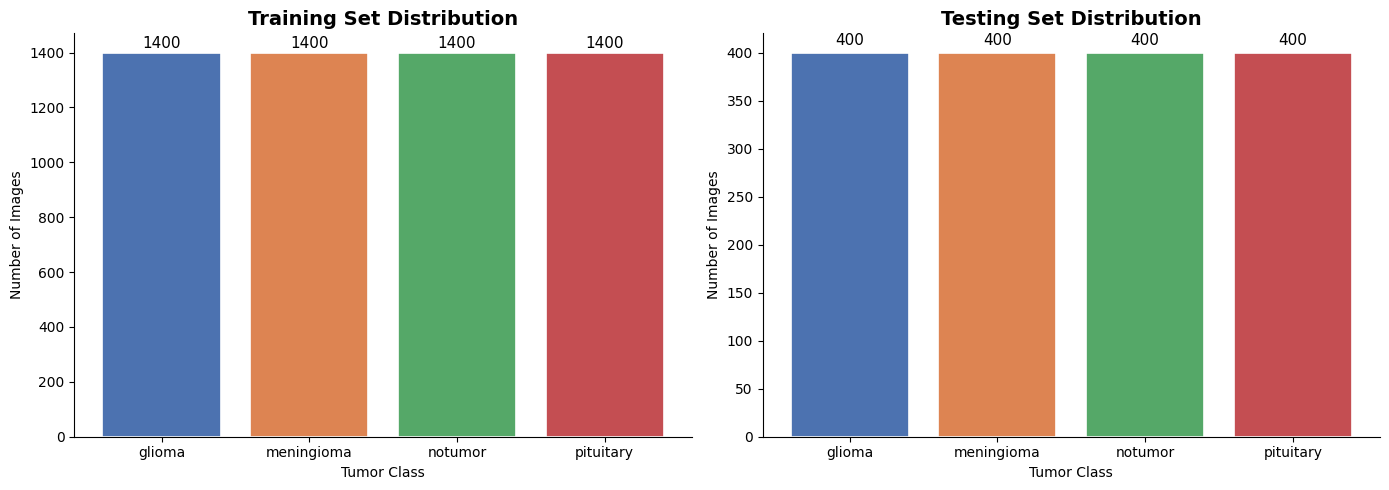

In [23]:
def count_images(directory):
    counts = {}
    directory = Path(directory)
    for cls in sorted(os.listdir(directory)):
        cls_path = directory / cls
        if cls_path.is_dir():
            counts[cls] = len(list(cls_path.glob('*.*')))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('Training samples per class:')
for cls, n in train_counts.items():
    print(f'  {cls:15s}: {n}')
print(f'  {"TOTAL":15s}: {sum(train_counts.values())}')

print('\nTesting samples per class:')
for cls, n in test_counts.items():
    print(f'  {cls:15s}: {n}')
print(f'  {"TOTAL":15s}: {sum(test_counts.values())}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (split, counts) in zip(axes, [('Training', train_counts), ('Testing', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{split} Set Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tumor Class')
    ax.set_ylabel('Number of Images')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

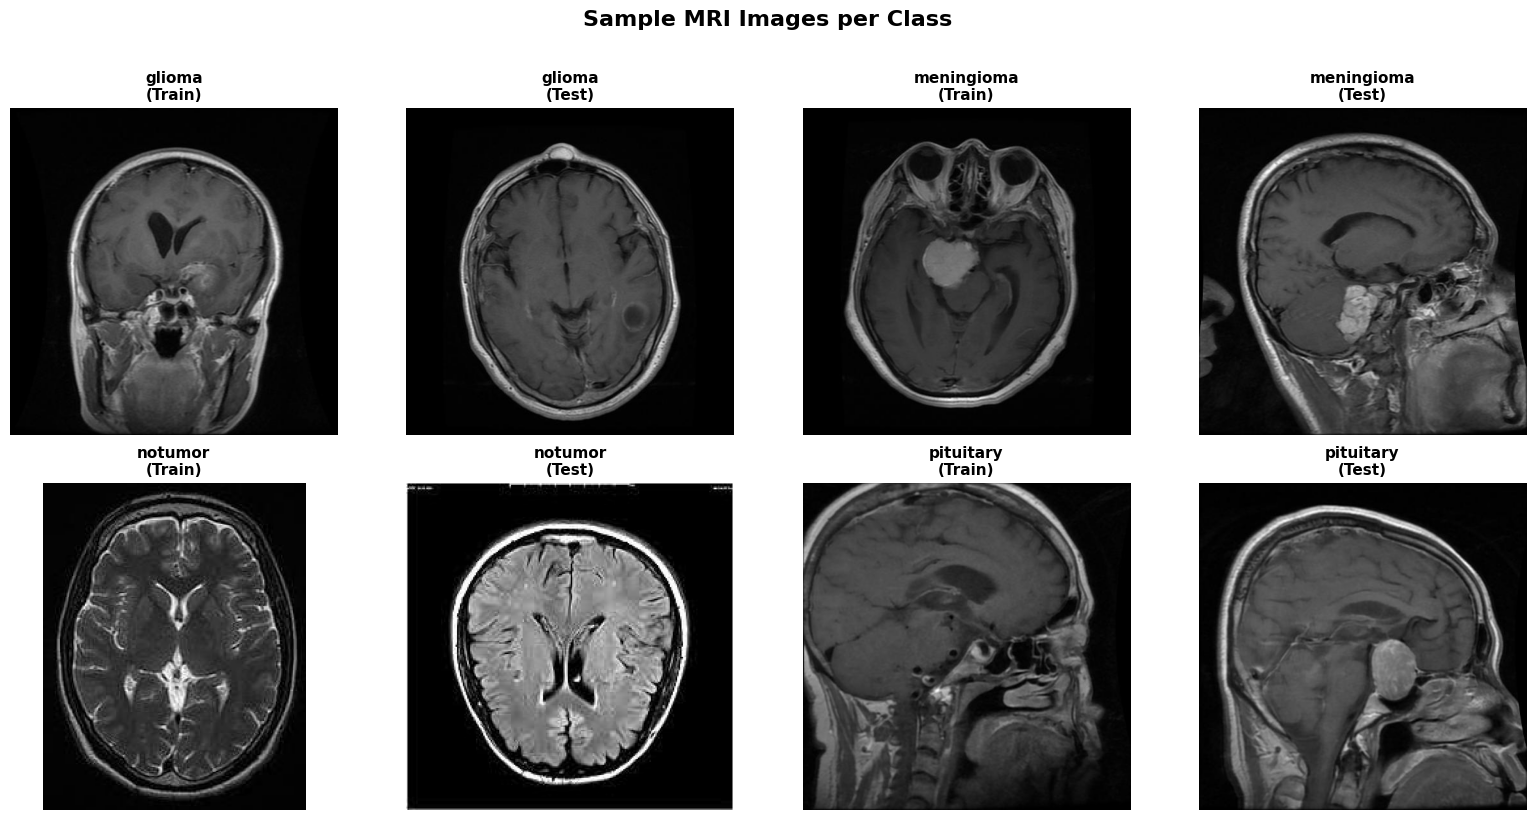

In [10]:
# ── Show sample images ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

idx = 0
for cls in CLASSES:
    for split, directory in [('Train', Path('/Users/ananyayyadav/Desktop/brain tumor mri /Testing')), ('Test', Path('/Users/ananyayyadav/Desktop/brain tumor mri /Training'))]:
        cls_path = directory / cls
        img_files = list(cls_path.glob('*.*'))
        img_path = random.choice(img_files)
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img)
        axes[idx].set_title(f'{cls}\n({split})', fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        idx += 1

plt.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Image Preprocessing & Data Augmentation

In [49]:
from pathlib import Path
from torchvision.datasets import ImageFolder

# ImageNet statistics (used for pretrained-compatible normalization)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Datasets & Loaders ─────────────────────────────────────────────────────
train_dataset = ImageFolder(root=Path('/Users/ananyayyadav/Desktop/brain tumor mri /Training'), transform=train_transform)
test_dataset  = ImageFolder(root=Path('/Users/ananyayyadav/Desktop/brain tumor mri /Testing'), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} images | {len(train_loader)} batches')
print(f'Test : {len(test_dataset)}  images | {len(test_loader)} batches')
print(f'Class mapping: {train_dataset.class_to_idx}')

Train: 5600 images | 175 batches
Test : 1600  images | 50 batches
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


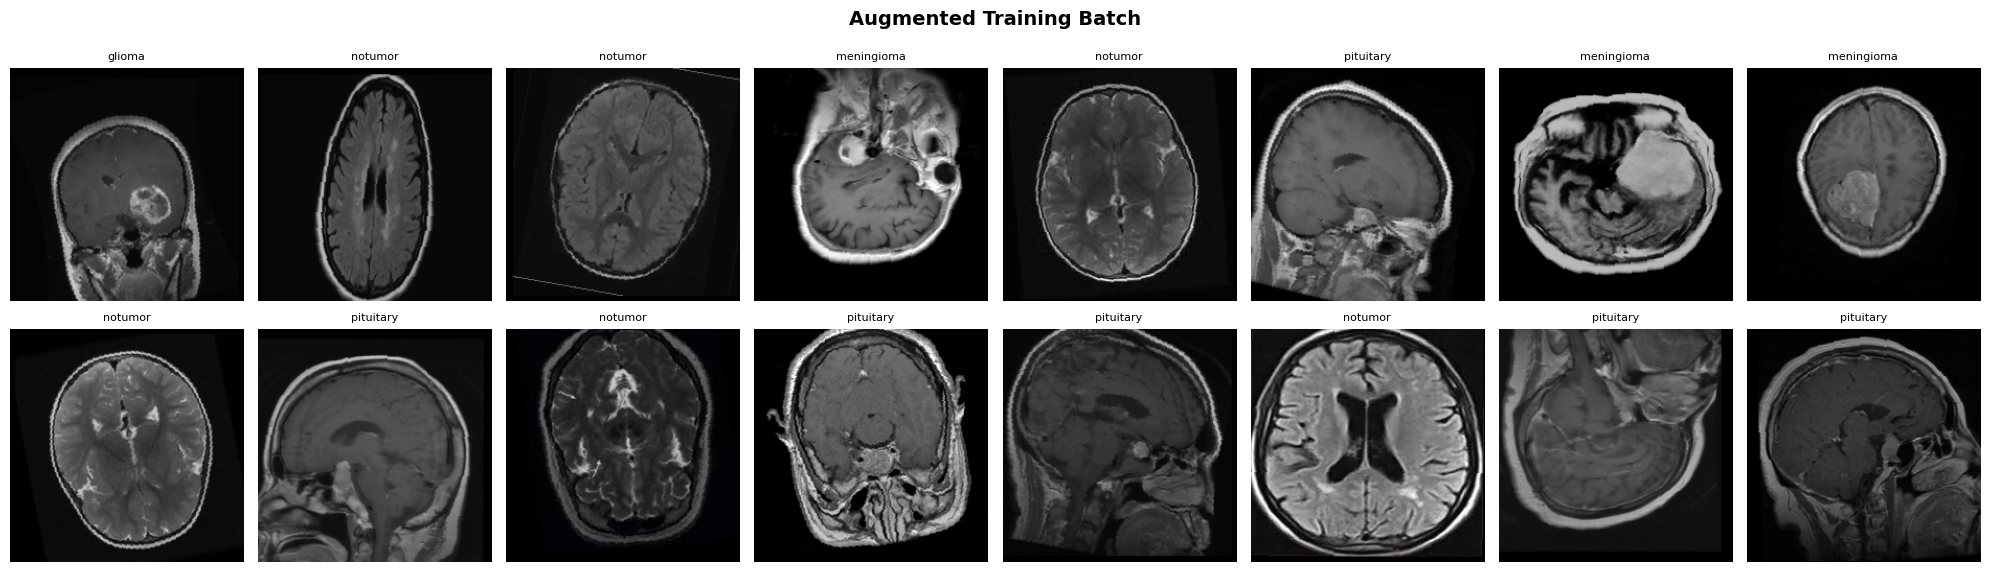

In [13]:
# ── Visualize augmented images ─────────────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flatten()[:16]):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_batch.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Vision Transformer (ViT) 

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Patch Embedding
# ─────────────────────────────────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """Split image into patches and project to embed_dim."""
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d as patch projection (equivalent to linear projection of flattened patches)
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, C, H, W) → (B, embed_dim, H/P, W/P)
        x = self.proj(x)
        # → (B, num_patches, embed_dim)
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x)


# ─────────────────────────────────────────────────────────────────────────────
# Multi-Head Self-Attention
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv    = nn.Linear(embed_dim, embed_dim * 3)
        self.proj   = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)   # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))


# ─────────────────────────────────────────────────────────────────────────────
# MLP Block
# ─────────────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4, dropout=0.0):
        super().__init__()
        hidden = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
# Transformer Encoder Block
# ─────────────────────────────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # residual
        x = x + self.mlp(self.norm2(x))    # residual
        return x


# ─────────────────────────────────────────────────────────────────────────────
# Vision Transformer
# ─────────────────────────────────────────────────────────────────────────────
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=4, embed_dim=256, depth=6,
                 num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional embeddings for patches + cls token
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
              for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        x   = torch.cat([cls, x], dim=1)                 # (B, N+1, D)
        x   = self.pos_drop(x + self.pos_embed)          # add pos embed
        x   = self.blocks(x)                             # transformer
        x   = self.norm(x)
        cls_out = x[:, 0]                                # CLS token
        return self.head(cls_out)


# ── Instantiate ───────────────────────────────────────────────────────────
model = VisionTransformer(
    img_size    = IMG_SIZE,
    patch_size  = PATCH_SIZE,
    num_classes = NUM_CLASSES,
    embed_dim   = EMBED_DIM,
    depth       = DEPTH,
    num_heads   = NUM_HEADS,
    mlp_ratio   = MLP_RATIO,
    dropout     = DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(model)

Total parameters    : 5,020,548
Trainable parameters: 5,020,548
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (proj_drop): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_featur

## 6. Training Setup

In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing with warm-up
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr     = LR,
    steps_per_epoch = len(train_loader),
    epochs     = NUM_EPOCHS,
    pct_start  = 0.1,          # 10% warm-up
    anneal_strategy = 'cos'
)

print('Criterion : CrossEntropyLoss (label_smoothing=0.1)')
print('Optimizer : AdamW')
print('Scheduler : OneCycleLR (cosine annealing + warm-up)')

Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW
Scheduler : OneCycleLR (cosine annealing + warm-up)


In [34]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# paths
TRAIN_PATH = "/Users/ananyayyadav/Desktop/brain tumor mri /Testing"
TEST_PATH  = "/Users/ananyayyadav/Desktop/brain tumor mri /Training"

# transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# datasets
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset  = datasets.ImageFolder(TEST_PATH, transform=transform)

# loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 7. Training Loop

In [13]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 33.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.9/679.9 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 41.7 MB/s eta 0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/11 [sympy]]
    Found existing installation: setuptools 82.0.1━━━━━━━━━━━━  2/11 [sympy]
    Uninstalling setuptools-82.0.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/11 [sympy]
      Successfully u

In [14]:
import torch
print(torch.__version__)

2.11.0


In [41]:
import sys
!{sys.executable} -m pip install timm
print("timm imported successfully")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
timm imported successfully


In [43]:
import timm
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=4)
model = model.to(DEVICE)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
def train_one_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Train'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [23]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

In [2]:
import timm

model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=4)
model = model.to(DEVICE)

print("Model ready")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model ready


In [10]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    return running_loss / total, correct / total

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# make path robust to the trailing-space variant you used earlier
DATA_ROOT = Path('/Users/ananyayyadav/Desktop/brain tumor mri ')
if not DATA_ROOT.exists():
    alt_root = Path('/Users/ananyayyadav/Desktop/brain tumor mri')
    if alt_root.exists():
        DATA_ROOT = alt_root
    else:
        raise FileNotFoundError(
            f"DATA_ROOT not found. Checked:\n"
            f"  {Path('/Users/ananyayyadav/Desktop/brain tumor mri ')}\n"
            f"  {Path('/Users/ananyayyadav/Desktop/brain tumor mri')}"
        )

TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR  = DATA_ROOT / 'Testing'

assert TRAIN_DIR.exists(), f'ERROR: {TRAIN_DIR} does not exist'
assert TEST_DIR.exists(),  f'ERROR: {TEST_DIR} does not exist'

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ DataLoader created successfully")

✅ DataLoader created successfully


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# make sure model exists BEFORE this
model = model.to(DEVICE)

NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_epoch = 0

PATIENCE = 5
counter = 0

for epoch in range(1, NUM_EPOCHS + 1):

    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch [{epoch}/{NUM_EPOCHS}] LR: {current_lr:.6f}")

    # ---- Training ----
    t_loss, t_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scheduler, DEVICE
    )

    # ---- Validation ----
    v_loss, v_acc, _, _ = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # ---- Store history ----
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    history['lr'].append(current_lr)

    print(f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc*100:.2f}%")
    print(f"Val   Loss: {v_loss:.4f}, Val   Acc: {v_acc*100:.2f}%")

    # ---- Save best model ----
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("🔥 Best model saved!")

    else:
        counter += 1

    # ---- Early stopping ----
    if counter >= PATIENCE:
        print("⛔ Early stopping triggered")
        break

print(f"\nBest Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")


Epoch [1/20] LR: 0.000050


Evaluating: 100%|██████████| 50/50 [01:30<00:00,  1.81s/it]


Train Loss: 0.2047, Train Acc: 92.79%
Val   Loss: 0.3722, Val   Acc: 91.69%
🔥 Best model saved!

Epoch [2/20] LR: 0.000050


Evaluating: 100%|██████████| 50/50 [01:30<00:00,  1.82s/it]


Train Loss: 0.0699, Train Acc: 97.57%
Val   Loss: 0.2830, Val   Acc: 94.56%
🔥 Best model saved!

Epoch [3/20] LR: 0.000049


...

Train Loss: 0.0019, Train Acc: 99.91%
Val   Loss: 0.5401, Val   Acc: 95.38%

Epoch [18/20] LR: 0.000003


Evaluating: 100%|██████████| 50/50 [01:30<00:00,  1.81s/it]


Train Loss: 0.0019, Train Acc: 99.91%
Val   Loss: 0.5416, Val   Acc: 95.38%

Epoch [19/20] LR: 0.000001


Evaluating: 100%|██████████| 50/50 [01:31<00:00,  1.83s/it]

Train Loss: 0.0018, Train Acc: 99.91%
Val   Loss: 0.5427, Val   Acc: 95.38%
⛔ Early stopping triggered

Best Accuracy: 95.38% at epoch 14


## 8. Training Curves (Loss & Accuracy per Epoch)

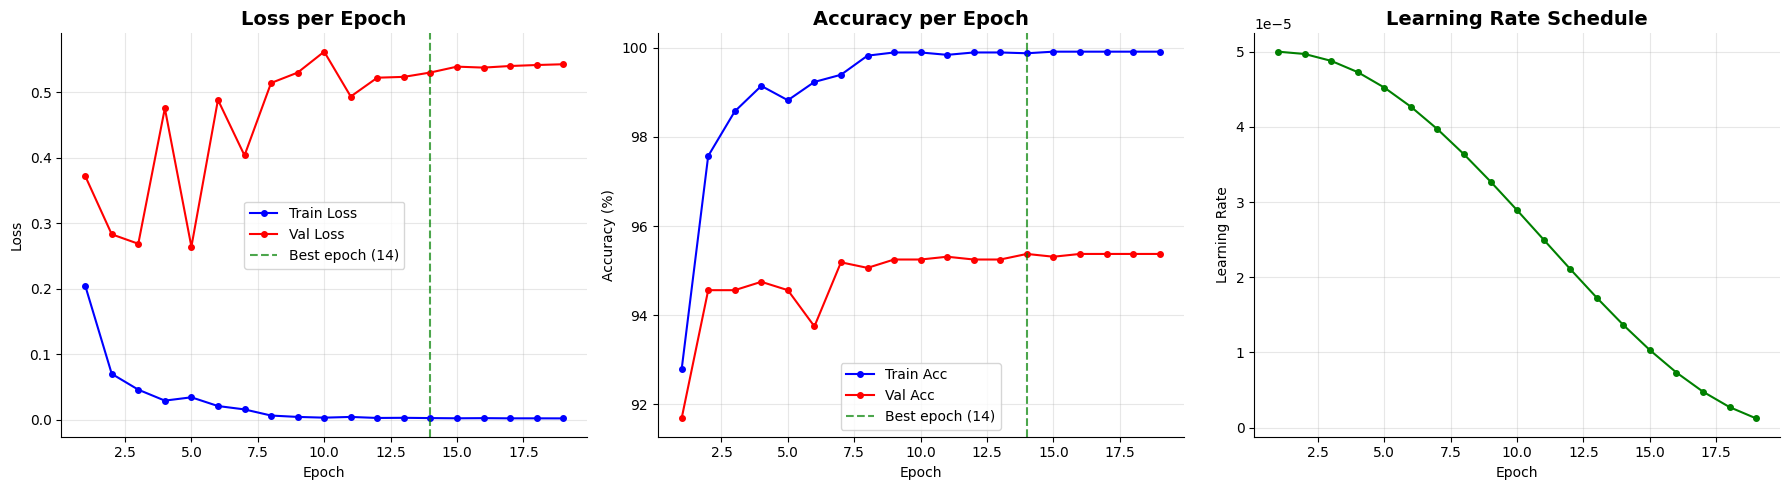

In [16]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss ──────────────────────────────────────────────────────────────────
axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Loss per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# ── Accuracy ──────────────────────────────────────────────────────────────
axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', markersize=4, label='Val Acc')
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

# ── Learning Rate ─────────────────────────────────────────────────────────
axes[2].plot(epochs, history['lr'], 'g-o', markersize=4)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].grid(True, alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation on Best Model

In [24]:
from sklearn.metrics import f1_score, classification_report

CLASSES = test_loader.dataset.classes
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))

_, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, DEVICE)

print('=' * 50)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test F1 (weighted): {f1_score(all_labels, all_preds, average="weighted")*100:.2f}%')
print('=' * 50)

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

Evaluating: 100%|██████████| 50/50 [01:29<00:00,  1.78s/it]

Test Accuracy : 95.38%
Test F1 (weighted): 95.28%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.83      0.91       400
  meningioma       0.90      0.99      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



## 10. Confusion Matrix

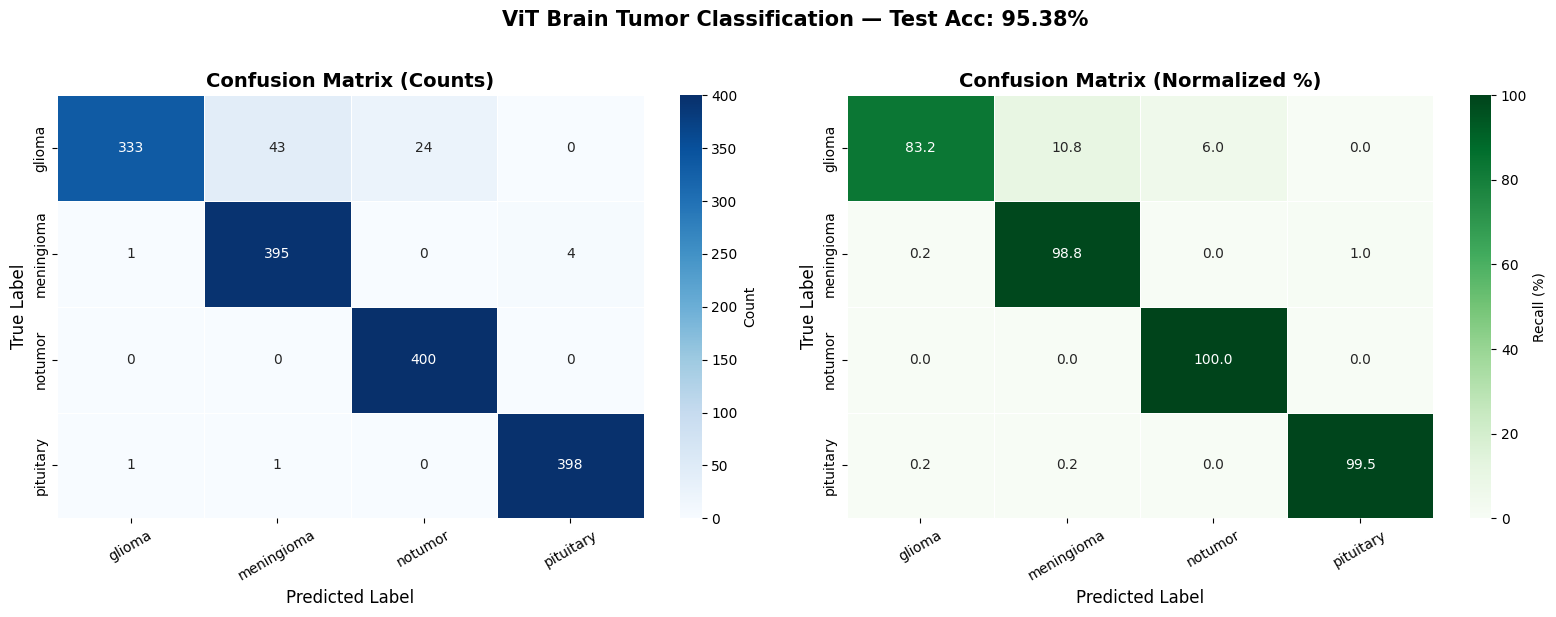

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Raw counts ────────────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='white',
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# ── Normalized (%) ────────────────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='white',
            ax=axes[1], cbar_kws={'label': 'Recall (%)'})
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'ViT Brain Tumor Classification — Test Acc: {test_acc*100:.2f}%',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Per-Class Metrics Bar Chart

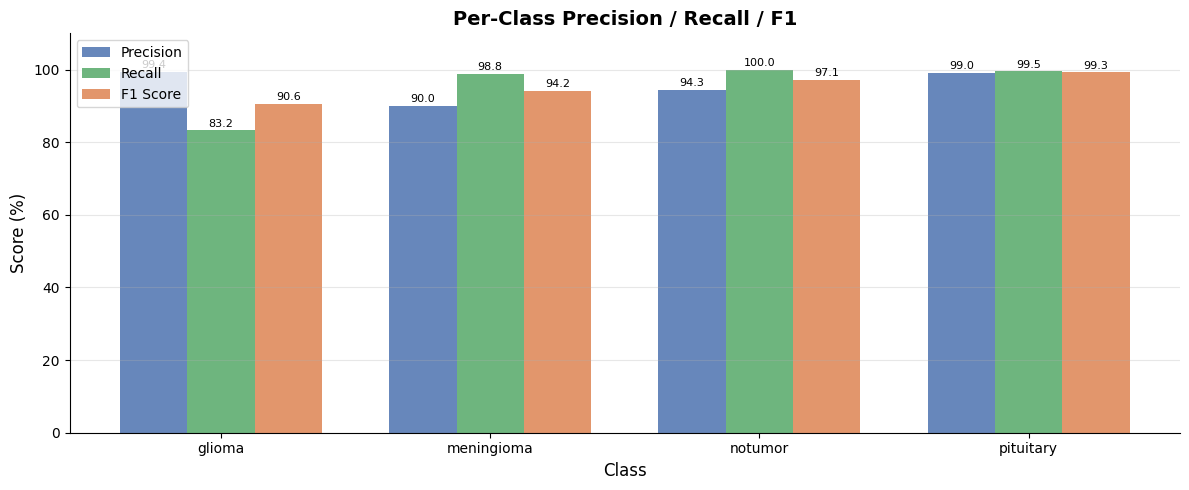

In [30]:
from sklearn.metrics import precision_score, recall_score

precisions = precision_score(all_labels, all_preds, average=None)
recalls    = recall_score(all_labels, all_preds, average=None)
f1s        = f1_score(all_labels, all_preds, average=None)

import numpy as np
x = np.arange(len(CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, precisions * 100, width, label='Precision', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x,         recalls    * 100, width, label='Recall',    color='#55A868', alpha=0.85)
bars3 = ax.bar(x + width, f1s        * 100, width, label='F1 Score',  color='#DD8452', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Per-Class Precision / Recall / F1', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Sample Predictions with Confidence

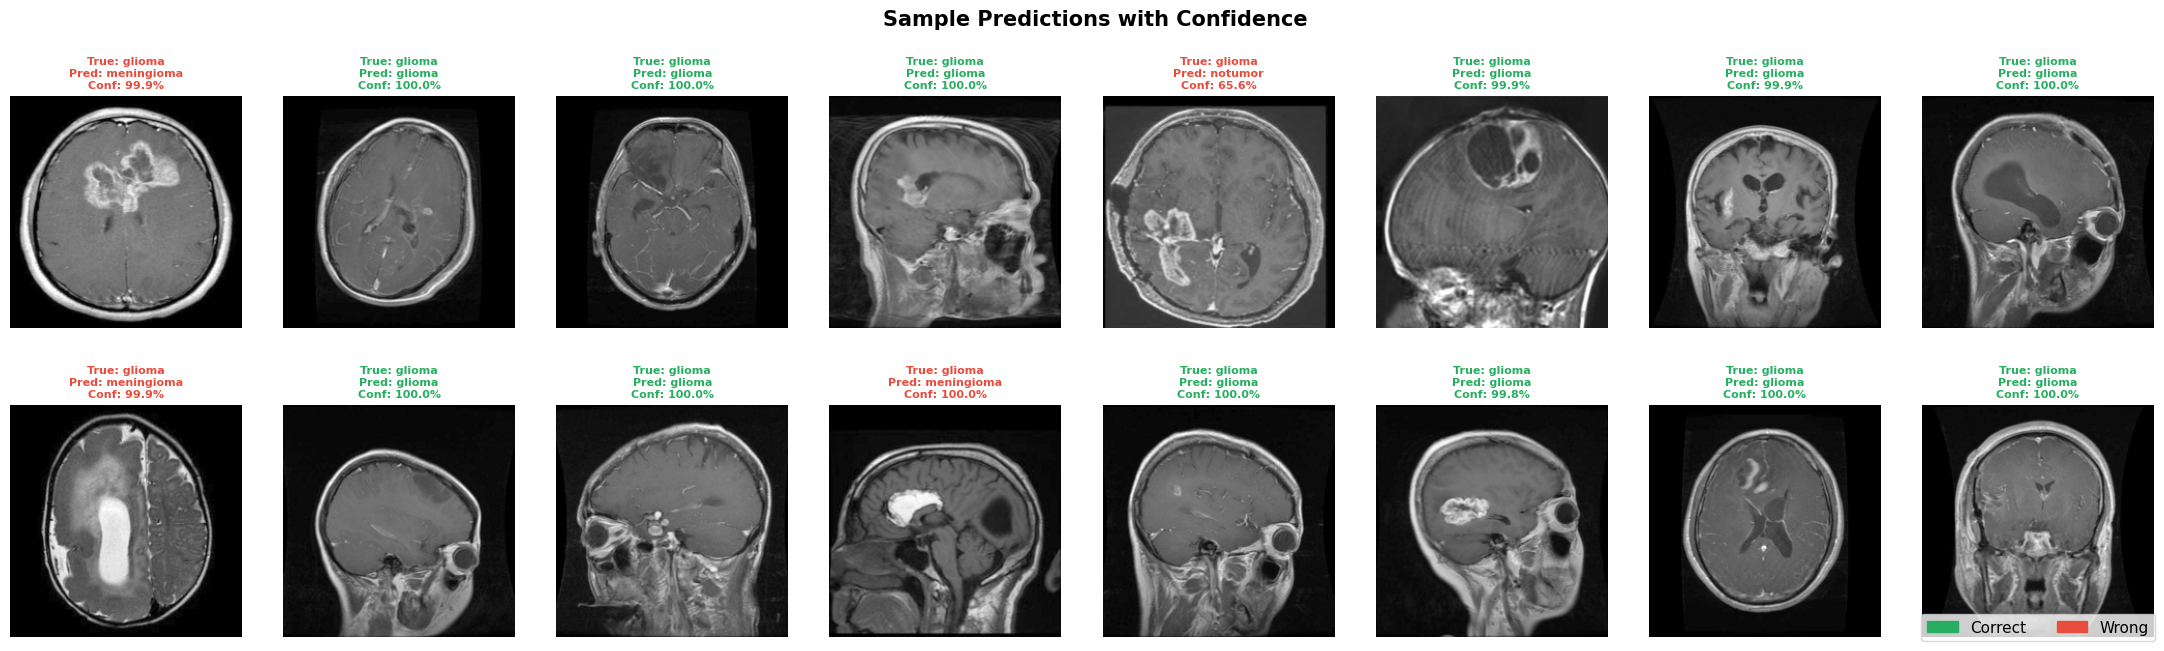

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

@torch.no_grad()
def predict_batch(model, loader, device, n=16):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:n].to(device), labels[:n].cpu()
    
    logits = model(images)
    probs  = torch.softmax(logits, dim=1).cpu()
    preds  = probs.argmax(dim=1)
    
    return images.cpu(), labels, preds, probs


# 🔥 Better denormalization (contrast stretch)
def denormalize(img):
    img = img.clone().detach()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img


imgs, true_lbls, pred_lbls, probs = predict_batch(model, test_loader, DEVICE)

fig, axes = plt.subplots(2, 8, figsize=(22, 7))
axes = axes.flatten()

for i in range(16):
    img = denormalize(imgs[i])

    # Convert to grayscale (MRI looks better)
    if img.shape[0] == 3:
        img = img.mean(dim=0)

    img = img.numpy()

    # 🔥 Improve visibility
    img = img ** 0.7   # gamma correction

    conf = probs[i, pred_lbls[i]].item() * 100
    correct = pred_lbls[i] == true_lbls[i]
    color   = '#27ae60' if correct else '#e74c3c'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f'True: {CLASSES[true_lbls[i]]}\n'
        f'Pred: {CLASSES[pred_lbls[i]]}\n'
        f'Conf: {conf:.1f}%',
        fontsize=8,
        color=color,
        fontweight='bold'
    )

    axes[i].axis('off')

    # Border highlight
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)


# Legend
correct_patch = mpatches.Patch(color='#27ae60', label='Correct')
wrong_patch   = mpatches.Patch(color='#e74c3c', label='Wrong')

plt.legend(handles=[correct_patch, wrong_patch],
           loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=2, fontsize=11)

plt.suptitle('Sample Predictions with Confidence', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig('sample_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

## 14. Summary

In [37]:
from sklearn.metrics import f1_score

PATCH_SIZE = 16
EMBED_DIM = 768
DEPTH = 12
NUM_HEADS = 12

total_params = sum(p.numel() for p in model.parameters())

print('=' * 55)
print('  BRAIN TUMOR MRI — ViT CLASSIFICATION SUMMARY')
print('=' * 55)

print(f'  Model        : Vision Transformer')
print(f'  Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Patch size   : {PATCH_SIZE}x{PATCH_SIZE}  ({(IMG_SIZE//PATCH_SIZE)**2} patches)')
print(f'  Embed dim    : {EMBED_DIM}')
print(f'  Depth        : {DEPTH} Transformer blocks')
print(f'  Heads        : {NUM_HEADS}')
print(f'  Parameters   : {total_params:,}')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Best epoch   : {best_epoch}')
print(f'  Best val acc : {best_val_acc*100:.2f}%')
print(f'  Test acc     : {test_acc*100:.2f}%')
print(f'  F1 (weighted): {f1_score(all_labels, all_preds, average="weighted")*100:.2f}%')

print('=' * 55)

  BRAIN TUMOR MRI — ViT CLASSIFICATION SUMMARY
  Model        : Vision Transformer
  Image size   : 224x224
  Patch size   : 16x16  (196 patches)
  Embed dim    : 768
  Depth        : 12 Transformer blocks
  Heads        : 12
  Parameters   : 85,801,732
  Epochs       : 20
  Best epoch   : 14
  Best val acc : 95.38%
  Test acc     : 95.38%
  F1 (weighted): 95.28%
